# Phase 1 -- Data Exploration and Preprocessing

## Objective

Prepare the raw RNA-Seq gene expression dataset for downstream analysis. The dataset contains expression values for approximately 20,000 genes across 801 tumor samples belonging to five cancer types (BRCA, KIRC, COAD, LUAD, PRAD).

### Preprocessing Pipeline

1. **Load** the raw Samples x Genes matrix
2. **Clean** -- remove identifiers, coerce to numeric
3. **Log transform** -- apply log2(X + 1) to stabilize variance and reduce skewness
4. **Z-score normalize** -- standardize each gene to zero mean and unit variance so all genes contribute equally
5. **Save** the processed matrix for subsequent phases

In [1]:
import sys
from pathlib import Path
import os
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load_data import load_uci_dataset
from src.data.preprocess import log_transform, zscore_normalize
from src.data.split_data import save_processed_data


## 1.1 Load the Raw Dataset

We load the UCI Gene Expression Cancer RNA-Seq dataset. The feature matrix X has shape (801, 20532) -- each row is a tumor sample and each column is a gene. The label vector y contains the cancer type for each sample.

In [2]:
X, y = load_uci_dataset(
    r"../Data/raw/data.csv",
    r"../Data/raw/labels.csv"
)

print("Feature matrix shape:", X.shape)
print("Label shape:", y.shape)


Feature matrix shape: (801, 20532)
Label shape: (801,)


In [3]:
assert X.shape[0] == y.shape[0], "Mismatch between samples and labels!"
print("✔ Data and labels are correctly aligned")


print("Missing values:", X.isnull().sum().sum())
print("Number of classes:", y.nunique())
print(y.head())
print(y.dtype)

✔ Data and labels are correctly aligned
Missing values: 0
Number of classes: 801
0    sample_0
1    sample_1
2    sample_2
3    sample_3
4    sample_4
Name: Unnamed: 0, dtype: object
object


## 1.2 Data Validation

We verify that the number of samples matches between X and y, check for missing values, and inspect the distribution of cancer class labels.

In [4]:
# plt.figure(figsize=(6,4))
# sns.histplot(X.iloc[:, 0], bins=50)
# plt.title("Raw Gene Expression Distribution (Sample Gene)")
# plt.show()


## 1.3 Log Transformation

Raw gene expression values are highly skewed -- a small number of genes have extremely large counts while most are near zero. To address this we apply a log2 transformation:

$$X_{\text{log}} = \log_2(X + 1)$$

The +1 avoids taking log of zero. This compresses the dynamic range, stabilizes variance, and makes the distribution more symmetric, which benefits both visualization and downstream modeling.

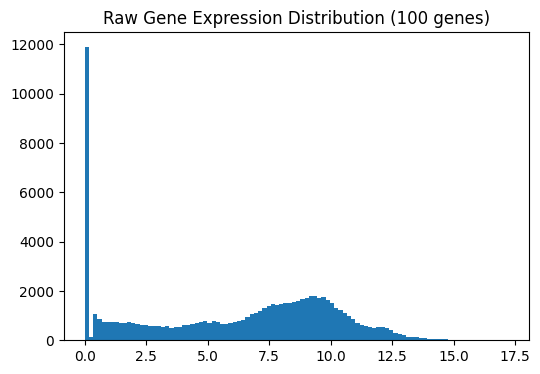

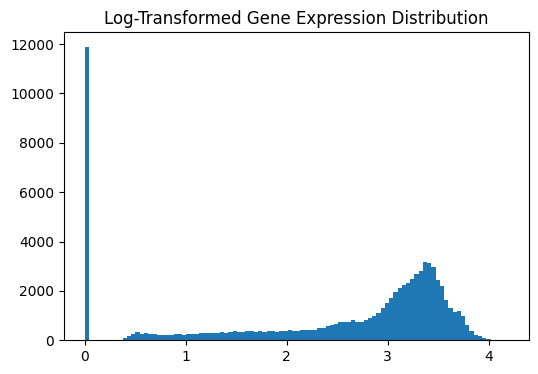

In [5]:
# Ensure numeric data
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)
X_numeric = X.fillna(0)
# Sample genes
sampled_genes = X.sample(n=100, axis=1, random_state=42)
values = sampled_genes.values.flatten()

# Raw distribution
plt.figure(figsize=(6,4))
plt.hist(values, bins=100)
plt.title("Raw Gene Expression Distribution (100 genes)")
plt.show()

# Log transform
X_log = np.log2(X_numeric + 1)

sampled_genes_log = X_log.sample(n=100, axis=1, random_state=42)
values_log = sampled_genes_log.values.flatten()

# Log distribution
plt.figure(figsize=(6,4))
plt.hist(values_log, bins=100)
plt.title("Log-Transformed Gene Expression Distribution")
plt.show()


## 1.4 Z-Score Normalization

After log transformation, each gene is standardized independently:

$$X_{\text{scaled}} = \frac{X - \mu}{\sigma}$$

This ensures every gene has mean 0 and standard deviation 1, preventing highly expressed genes from dominating the analysis purely due to scale differences.

In [6]:
X_norm = zscore_normalize(X_log)

print("Mean (approx):", X_norm.mean().mean())
print("Std (approx):", X_norm.std().mean())


Mean (approx): -1.3396894169761933e-18
Std (approx): 0.9875638537239041


## 1.5 Save Processed Data

The fully preprocessed matrix (log-transformed and z-score normalized) is saved to `Data/processed/X_processed.csv` along with the corresponding labels. All subsequent notebooks load from this processed dataset to ensure consistency across the pipeline.

In [7]:
save_processed_data(X_norm, y, "..\Data\processed")